# 01 · EDA: Google Play Store Apps
**Group 10: Mobile App Ecosystem Dynamics and Direct Bank Marketing Pipelines**

Dataset: https://www.kaggle.com/datasets/lava18/google-play-store-apps

Goal: understand what drives app ratings, installs and engagement across categories,
and whether free and paid apps behave differently.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.viz import *

set_style()
pd.set_option("display.max_columns", 30)
df_raw = pd.read_csv(RAW / "play_store" / "googleplaystore.csv")
print(df_raw.shape)
df_raw.head()

(10841, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## 1. Data quality audit

In [2]:
audit = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "missing_%": (df_raw.isna().mean() * 100).round(2),
    "unique": df_raw.nunique(),
})
print("Exact duplicate rows:", df_raw.duplicated().sum())
print("Duplicate app names:", df_raw["App"].duplicated().sum())
audit

Exact duplicate rows: 483
Duplicate app names: 1181


,dtype,missing,missing_%,unique
App,str,0,0.00,9660
Category,str,0,0.00,34
Rating,float64,1474,13.60,40
Reviews,str,0,0.00,6002
Size,str,0,0.00,462
Installs,str,0,0.00,22
Type,str,1,0.01,3
Price,str,0,0.00,93
Content Rating,str,1,0.01,6
Genres,str,0,0.00,120


In [3]:
# Row whose columns are shifted by one (Category = '1.9', Rating = 19)
df_raw[~df_raw["Reviews"].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


## 2. Cleaning
- Drop the corrupted row and exact duplicates; keep one row per app (the one with most reviews = latest scrape).
- Convert text columns to numbers: `Reviews`, `Size` (k/M → MB, "Varies with device" → NaN), `Installs` ("10,000+" → 10000), `Price` ("$4.99" → 4.99).
- Parse `Last Updated` as a date.
- `Rating` missing for ~15 % of apps: these are almost all low-install apps with too few ratings, so we **keep them as NaN** for rating analysis rather than impute a fake score.

In [4]:
df = df_raw[df_raw["Reviews"].str.isnumeric()].copy()
df = df.drop_duplicates()
df["Reviews"] = df["Reviews"].astype(int)
df = df.sort_values("Reviews", ascending=False).drop_duplicates("App").reset_index(drop=True)

def size_mb(s):
    if s.endswith("M"):
        return float(s[:-1])
    if s.endswith("k"):
        return float(s[:-1]) / 1024
    return np.nan

df["Size_MB"] = df["Size"].map(size_mb)
df["Installs_n"] = df["Installs"].str.replace(r"[+,]", "", regex=True).astype(int)
df["Price_usd"] = df["Price"].str.replace("$", "", regex=False).astype(float)
df["Last_Updated"] = pd.to_datetime(df["Last Updated"], format="%B %d, %Y")
df["Days_Since_Update"] = (df["Last_Updated"].max() - df["Last_Updated"]).dt.days
df["Type"] = np.where(df["Price_usd"] > 0, "Paid", "Free")
df["Primary_Genre"] = df["Genres"].str.split(";").str[0]
df["Log_Installs"] = np.log10(df["Installs_n"].clip(lower=1))
df["Log_Reviews"] = np.log10(df["Reviews"] + 1)

print(f"Rows: raw {len(df_raw):,} → clean {len(df):,} ({len(df_raw) - len(df):,} removed)")
print("Rating missing after cleaning:", df["Rating"].isna().sum(), f"({df['Rating'].isna().mean():.1%})")
print("Size unknown ('Varies with device'):", df["Size_MB"].isna().sum())
df.to_csv(PROCESSED / "play_store_clean.csv", index=False)
df[["Rating", "Reviews", "Size_MB", "Installs_n", "Price_usd", "Days_Since_Update"]].describe().T.round(2)

Rows: raw 10,841 → clean 9,659 (1,182 removed)
Rating missing after cleaning: 1463 (15.1%)
Size unknown ('Varies with device'): 1228


,count,mean,std,min,25%,50%,75%,max
Rating,8196.0,4.17,0.54,1.00,4.0,4.3,4.5,5.000000e+00
Reviews,9659.0,216804.11,1831430.21,0.00,25.0,969.0,29453.5,7.815831e+07
Size_MB,8431.0,20.40,21.83,0.01,4.6,12.0,28.0,1.000000e+02
Installs_n,9659.0,7798170.25,53769728.82,0.00,1000.0,100000.0,1000000.0,1.000000e+09
Price_usd,9659.0,1.10,16.85,0.00,0.0,0.0,0.0,4.000000e+02
Days_Since_Update,9659.0,281.01,406.72,0.00,22.0,96.0,366.0,3.001000e+03


In [5]:
missing_by_install = df.assign(missing=df["Rating"].isna()).groupby("Installs_n")["missing"].mean()
print("Share of apps with missing rating, by install bucket:")
print((missing_by_install * 100).round(1).head(10))

Share of apps with missing rating, by install bucket:
Installs_n
0        100.0
1         95.5
5         89.0
10        82.1
50        72.5
100       57.4
500       39.3
1000      21.5
5000       9.2
10000      4.3
Name: missing, dtype: float64


## 3. Univariate analysis

findfont: Failed to find font weight semibold for Helvetica Neue, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


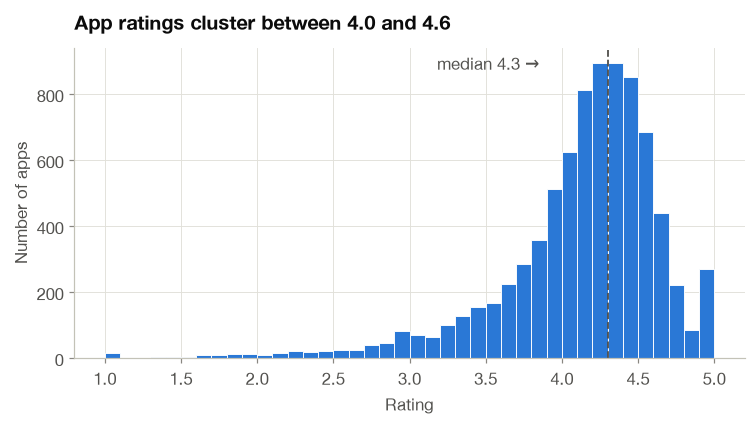

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["Rating"].dropna(), bins=np.arange(1, 5.1, 0.1), color=BLUE, edgecolor=SURFACE, linewidth=0.6)
med = df["Rating"].median()
ax.axvline(med, color=INK_2, lw=1.2, ls="--")
ax.text(med - 0.45, ax.get_ylim()[1] * 0.93, f"median {med:.1f} →", ha="right", color=INK_2)
ax.set(title="App ratings cluster between 4.0 and 4.6", xlabel="Rating", ylabel="Number of apps")
save(fig, "ps_rating_distribution")

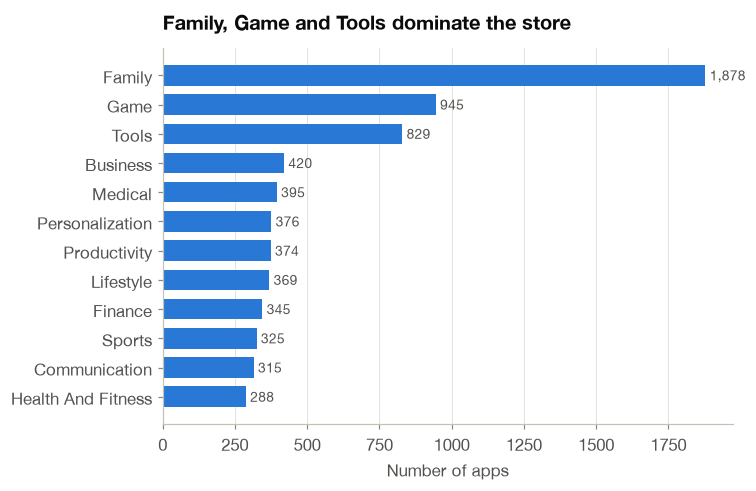

In [7]:
top_cat = df["Category"].value_counts().head(12).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.barh(top_cat.index.str.replace("_", " ").str.title(), top_cat.values, color=BLUE, height=0.7)
for y, v in enumerate(top_cat.values):
    ax.text(v + 15, y, f"{v:,}", va="center", fontsize=9, color=INK_2)
ax.set(title="Family, Game and Tools dominate the store", xlabel="Number of apps")
ax.grid(axis="y", visible=False)
save(fig, "ps_top_categories")

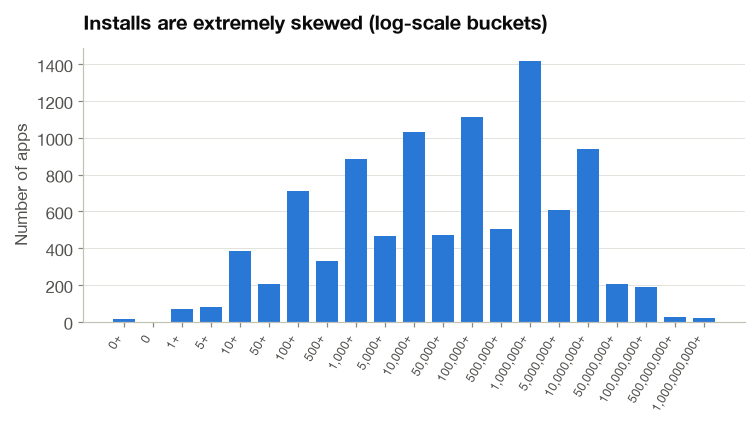

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
inst = df["Installs"].value_counts()
inst = inst.reindex(sorted(inst.index, key=lambda s: int(s.replace(",", "").replace("+", ""))))
ax.bar(range(len(inst)), inst.values, color=BLUE, width=0.75)
ax.set_xticks(range(len(inst)), inst.index, rotation=60, ha="right", fontsize=8)
ax.set(title="Installs are extremely skewed (log-scale buckets)", ylabel="Number of apps")
ax.grid(axis="x", visible=False)
save(fig, "ps_installs_distribution")

## 4. Bivariate analysis

In [9]:
cat_stats = (df.groupby("Category")
               .agg(apps=("App", "size"), median_installs=("Installs_n", "median"),
                    total_installs=("Installs_n", "sum"), mean_rating=("Rating", "mean"))
               .sort_values("total_installs", ascending=False))
cat_stats.head(10)

,apps,median_installs,total_installs,mean_rating
Category,,,,
GAME,945,1000000.0,13447924415,4.244432
COMMUNICATION,315,100000.0,11038276251,4.121484
TOOLS,829,50000.0,8102771915,4.040278
FAMILY,1878,50000.0,6237542505,4.184150
PRODUCTIVITY,374,100000.0,5793091369,4.183389
SOCIAL,239,100000.0,5487867902,4.247291
PHOTOGRAPHY,281,1000000.0,4658147655,4.155894
VIDEO_PLAYERS,164,1000000.0,3931902720,4.044966
TRAVEL_AND_LOCAL,219,100000.0,2894887146,4.069519


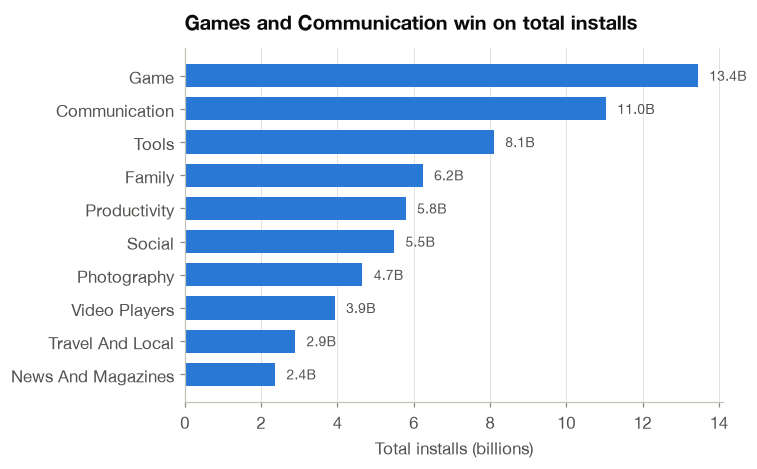

In [10]:
top_inst = (cat_stats["total_installs"].head(10) / 1e9).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.4))
ax.barh(top_inst.index.str.replace("_", " ").str.title(), top_inst.values, color=BLUE, height=0.7)
for y, v in enumerate(top_inst.values):
    ax.text(v + 0.3, y, f"{v:.1f}B", va="center", fontsize=9, color=INK_2)
ax.set(title="Games and Communication win on total installs", xlabel="Total installs (billions)")
ax.grid(axis="y", visible=False)
save(fig, "ps_installs_by_category")

findfont: Failed to find font weight semibold for Helvetica Neue, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


,apps,mean_rating,median_installs,median_reviews
Type,,,,
Free,8905,4.166223,100000.0,1379.0
Paid,754,4.262126,1000.0,88.5


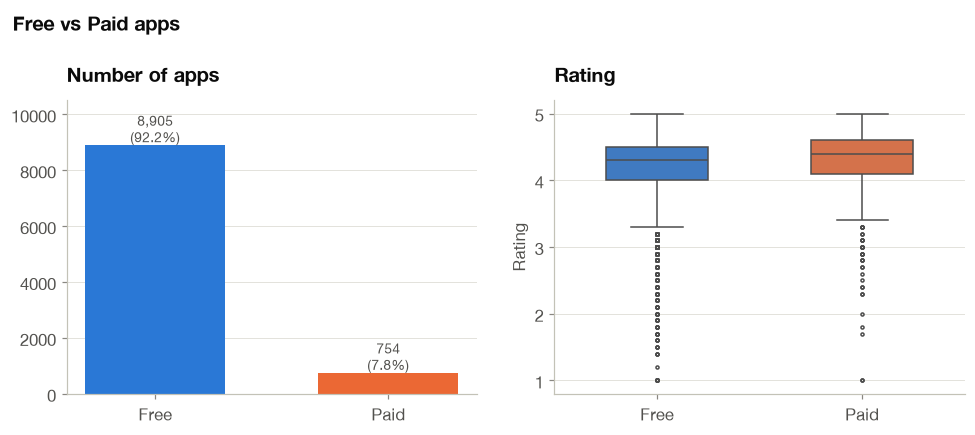

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
share = df["Type"].value_counts()
axes[0].bar(share.index, share.values, color=[SERIES[0], SERIES[1]], width=0.6)
for i, v in enumerate(share.values):
    axes[0].text(i, v + 100, f"{v:,}\n({v / share.sum():.1%})", ha="center", color=INK_2, fontsize=9)
axes[0].set(title="Number of apps", ylim=(0, share.max() * 1.18))
axes[0].grid(axis="x", visible=False)
sns.boxplot(data=df, x="Type", y="Rating", order=share.index, hue="Type", hue_order=share.index,
            palette=[SERIES[0], SERIES[1]], width=0.5, fliersize=2, linewidth=1, ax=axes[1], legend=False)
axes[1].set(title="Rating", xlabel="")
fig.suptitle("Free vs Paid apps", x=0.02, ha="left", fontweight="semibold")
save(fig, "ps_free_vs_paid")
df.groupby("Type").agg(apps=("App", "size"), mean_rating=("Rating", "mean"),
                       median_installs=("Installs_n", "median"), median_reviews=("Reviews", "median"))

,Rating,Log_Reviews,Log_Installs,Size_MB,Price_usd,Days_Since_Update
Rating,1.00,0.12,0.03,0.05,0.07,-0.18
Log_Reviews,0.12,1.00,0.97,0.33,-0.15,-0.34
Log_Installs,0.03,0.97,1.00,0.31,-0.23,-0.33
Size_MB,0.05,0.33,0.31,1.00,-0.05,-0.31
Price_usd,0.07,-0.15,-0.23,-0.05,1.00,0.15
Days_Since_Update,-0.18,-0.34,-0.33,-0.31,0.15,1.00


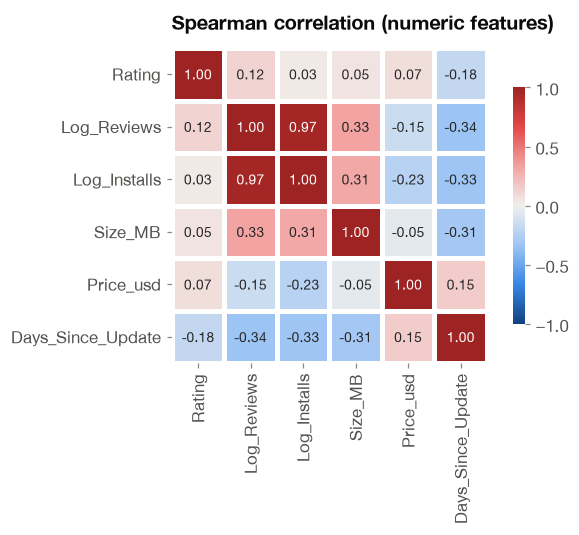

In [12]:
num = df[["Rating", "Log_Reviews", "Log_Installs", "Size_MB", "Price_usd", "Days_Since_Update"]]
corr = num.corr(method="spearman")
fig, ax = plt.subplots(figsize=(6.4, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=DIVERGING, vmin=-1, vmax=1, square=True,
            linewidths=2, linecolor=SURFACE, cbar_kws={"shrink": 0.75}, ax=ax,
            annot_kws={"fontsize": 9})
ax.set(title="Spearman correlation (numeric features)")
ax.grid(False)
save(fig, "ps_correlation")
corr.round(2)

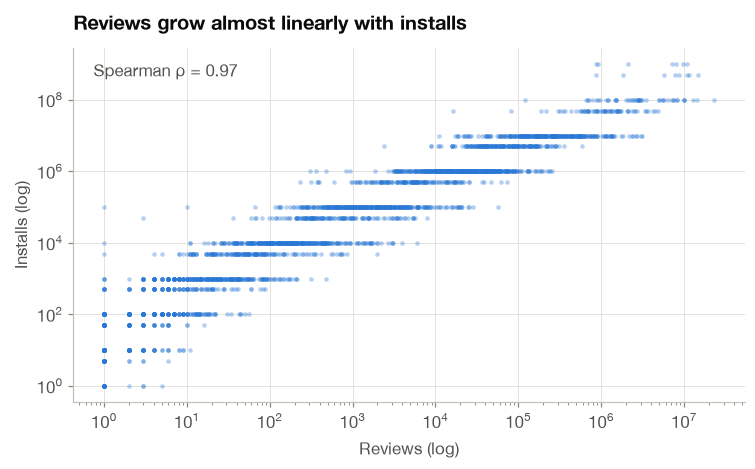

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.4))
sample = df.sample(3000, random_state=0)
ax.scatter(sample["Reviews"] + 1, sample["Installs_n"].clip(lower=1), s=9, alpha=0.35, color=BLUE, linewidths=0)
ax.set(xscale="log", yscale="log", xlabel="Reviews (log)", ylabel="Installs (log)",
       title="Reviews grow almost linearly with installs")
rho = df[["Reviews", "Installs_n"]].corr(method="spearman").iloc[0, 1]
ax.text(0.03, 0.92, f"Spearman ρ = {rho:.2f}", transform=ax.transAxes, color=INK_2)
save(fig, "ps_reviews_vs_installs")

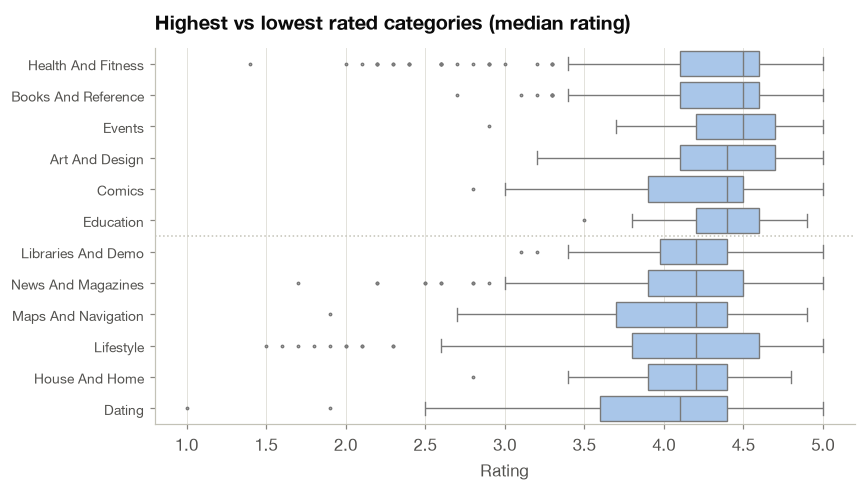

In [14]:
order = (df.groupby("Category")["Rating"].median().sort_values(ascending=False))
sel = list(order.index[:6]) + list(order.index[-6:])
fig, ax = plt.subplots(figsize=(8, 4.6))
sns.boxplot(data=df[df["Category"].isin(sel)], y="Category", x="Rating", order=sel, color="#9ec5f4",
            fliersize=1.5, linewidth=0.9, ax=ax)
ax.set_yticks(range(len(sel)), [s.replace("_", " ").title() for s in sel], fontsize=9)
ax.set(title="Highest vs lowest rated categories (median rating)", ylabel="")
ax.axhline(5.5, color=AXIS, lw=1, ls=":")
save(fig, "ps_rating_by_category")

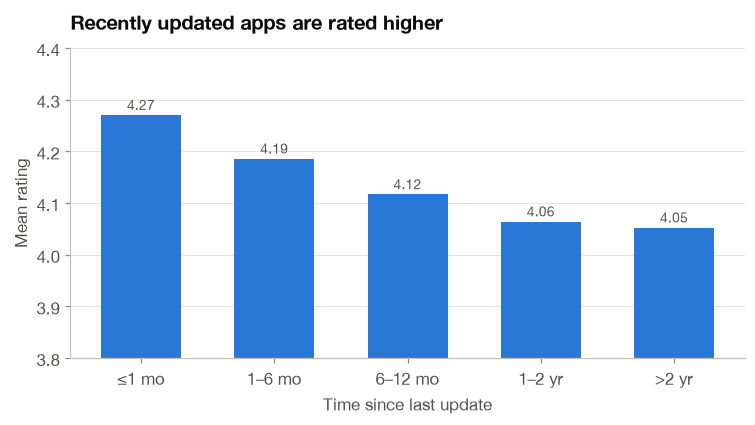

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
df["Update_Year"] = df["Last_Updated"].dt.year
upd = df.groupby(pd.cut(df["Days_Since_Update"], [-1, 30, 180, 365, 730, 5000],
                        labels=["≤1 mo", "1–6 mo", "6–12 mo", "1–2 yr", ">2 yr"]), observed=True)["Rating"].mean()
ax.bar(upd.index.astype(str), upd.values, color=BLUE, width=0.6)
for i, v in enumerate(upd.values):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center", color=INK_2, fontsize=9)
ax.set(ylim=(3.8, 4.4), title="Recently updated apps are rated higher", xlabel="Time since last update",
       ylabel="Mean rating")
ax.grid(axis="x", visible=False)
save(fig, "ps_rating_vs_update")

## 5. Key insights

In [16]:
paid = df[df["Type"] == "Paid"]
insights = {
    "rows_raw": len(df_raw), "rows_clean": len(df), "removed": len(df_raw) - len(df),
    "rating_missing_pct": df["Rating"].isna().mean() * 100,
    "rating_median": df["Rating"].median(),
    "rating_share_ge4": (df["Rating"] >= 4).mean() / df["Rating"].notna().mean() * 100,
    "free_share": (df["Type"] == "Free").mean() * 100,
    "free_rating": df.loc[df["Type"] == "Free", "Rating"].mean(),
    "paid_rating": paid["Rating"].mean(),
    "free_median_installs": df.loc[df["Type"] == "Free", "Installs_n"].median(),
    "paid_median_installs": paid["Installs_n"].median(),
    "paid_median_price": paid["Price_usd"].median(),
    "top_category_count": df["Category"].value_counts().index[0],
    "top_category_installs": cat_stats.index[0],
    "top_category_installs_B": cat_stats["total_installs"].iloc[0] / 1e9,
    "spearman_reviews_installs": rho,
    "spearman_rating_reviews": corr.loc["Rating", "Log_Reviews"],
    "spearman_rating_size": corr.loc["Rating", "Size_MB"],
    "spearman_rating_update": corr.loc["Rating", "Days_Since_Update"],
    "rating_recent_update": upd.iloc[0], "rating_old_update": upd.iloc[-1],
    "best_category": order.index[0], "worst_category": order.index[-1],
    "missing_rating_low_installs_pct": df.loc[df["Rating"].isna(), "Installs_n"].le(1000).mean() * 100,
}
save_json(insights, "play_store_insights")
pd.Series(insights)

rows_raw                                        10841
rows_clean                                       9659
removed                                          1182
rating_missing_pct                          15.146495
rating_median                                     4.3
rating_share_ge4                             76.70815
free_share                                  92.193809
free_rating                                  4.166223
paid_rating                                  4.262126
free_median_installs                         100000.0
paid_median_installs                           1000.0
paid_median_price                                2.99
top_category_count                             FAMILY
top_category_installs                            GAME
top_category_installs_B                     13.447924
spearman_reviews_installs                    0.967714
spearman_rating_reviews                      0.119634
spearman_rating_size                          0.05024
spearman_rating_update      

**Insights**
1. **Ratings are inflated**: median 4.3, and ~77 % of rated apps score ≥ 4.0, so rating alone separates apps weakly.
2. **Missing ratings are not random**: most unrated apps have ≤ 1,000 installs; they are simply too new/small to be rated.
3. **Supply ≠ demand**: Family has the most apps, but Game and Communication capture the most installs.
4. **Free dominates** (~92 % of apps) with a median of 100K installs vs 1K for paid; paid apps are rated slightly higher (small, engaged audience).
5. **Reviews track installs** (ρ ≈ 0.97), so reviews are a strong proxy for popularity; rating is only weakly related to either.
6. **Maintenance matters**: apps updated in the last month have noticeably higher ratings than apps left for > 2 years.